# Conceptual

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [ ]:
import pandas as pd
from scipy.cluster.hierarchy import linkage, dendrogram

## Q1.
```{admonition}
:class: note
This problem involves the K-means clustering algorithm.

```{admonition}
:class: note
(a) Prove
$$
\frac{1}{|C_{k}|} \sum_{i,i'\in C_{k}} \sum_{j=1}^{p} (x_{ij}-x_{i'j})^{2} = 2\sum_{i\in C_{k}} \sum_{j=1}^{p} (x_{ij}-\overline{x}_{kj})^{2}
$$

Let $X_{1}, X_{2}\overset{\text{iid}}{\sim} (\operatorname{unif}\{1,|C_{k}|\})^{p}$. Using identical distribution, we have
\begin{align*}
\operatorname{Var}(X_{1}-X_{2})
&= \operatorname{E}((X_{1}-X_{2})(X_{1}-X_{2})^{T})-\operatorname{E}(X_{1}-X_{2})\operatorname{E}(X_{1}-X_{2})^{T}\\
&= \operatorname{E}((X_{1}-X_{2})(X_{1}-X_{2})^{T})
\end{align*}
as $\operatorname{E}(X_{1}-X_{2}) = \operatorname{E}(X_{1})-\operatorname{E}(X_{2}) = \mathbf{0}$. However, also using independence we also have
$$
\operatorname{Var}(X_{1}-X_{2}) = \operatorname{Var}(X_{1})+\operatorname{Var}(X_{2})-2\operatorname{Cov}(X_{1},X_{2}) = 2\operatorname{Var}(X_{1}).
$$

Dividing the identity to prove by $|C_{k}|$ we find the left side is $\operatorname{E}((X_{1}-X_{2})(X_{1}-X_{2})^{T})$ and the right side is $2\operatorname{Var}(X_{1})$.

```{admonition}
:class: note
(b) On the basis of this identity, argue that the $K$-means clustering algorithm decreases the objective
$$
\underset{C_{1},\dots,C_{k}}{\min}\left(\sum_{k=1}^{K}\frac{1}{|C_{k}|} \sum_{i,i'\in C_{k}} \sum_{j=1}^{p} (x_{ij}-x_{i'j})^{2} \right)
$$
at each iteration.

The identity means we can instead look at
$$
\sum_{k=1}^{K} \sum_{i\in C_{k}} \sum_{j=1}^{p} (x_{ij}-\overline{x}_{kj})^{2}.
$$
In the first step of iteration, we computer cluster centroids. This is done specifically to minimize the expression in the sum, so this step is non-increasing. For the second step, we update points to have label corresponding to their nearest centroid. If a point has its label updated, it is only because there was a closer centroid which then decreases the sum.

## Q2.
```{admonition}
:class: note
Suppose that we have four observations, for which we compute a dissimilarity matrix, given by

$$
\begin{bmatrix}
    & 0.3 & 0.4 & 0.7\\
0.3 &     & 0.5 & 0.8\\
0.4 & 0.5 &     & 0.45\\
0.7 & 0.8 & 0.45&
\end{bmatrix}.
$$

```{admonition}
:class: note
(a) On the basis of this dissimilarity matrix, sketch the dendrogram that results from hierarchically clustering these four observations using complete linkage. Be sure to indicate on the plot the height at which each fusion occurs, as well as the observations corresponding to each leaf in the dendrogram.

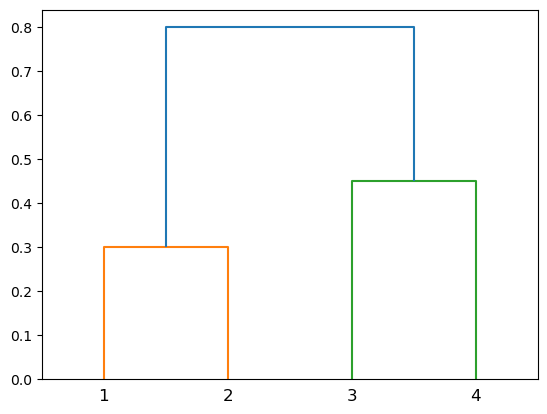

In [3]:
dendrogram(linkage([0.3,0.4,0.7,0.5,0.8,0.45],method='complete'),labels=[1,2,3,4],show_leaf_counts=True)
plt.show()

```{admonition}
:class: note
(b) Repeat (a), this time using single linkage clustering.

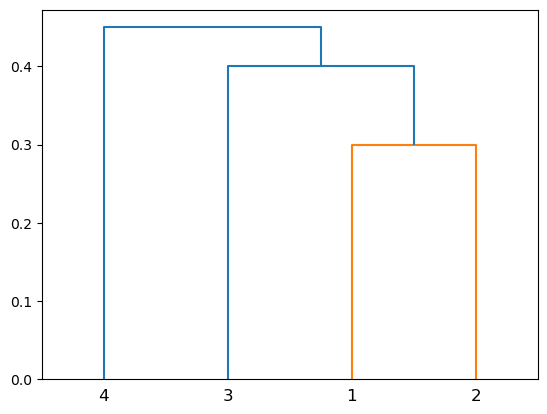

In [4]:
dendrogram(linkage([0.3,0.4,0.7,0.5,0.8,0.45],method='single'),labels=[1,2,3,4],show_leaf_counts=True)
plt.show()

```{admonition}
:class: note
(c) Suppose that we cut the dendrogram obtained in (a) such that two clusters result. Which observations are in each cluster?

$\{1,2\}$ and  $\{3,4\}$

```{admonition}
:class: note
(d) Suppose that we cut the dendrogram obtained in (b) such that two clusters result. Which observations are in each cluster?

$\{1,2,3\}$ and  $\{4\}$

```{admonition}
:class: note
(e) It is mentioned in this chapter that at each fusion in the dendrogram, the position of the two clusters being fused can be swapped without changing the meaning of the dendrogram. Draw a dendrogram that is equivalent to the dendrogram in (a), for which two or more of the leaves are repositioned, but for which the meaning of the dendrogram is the same.

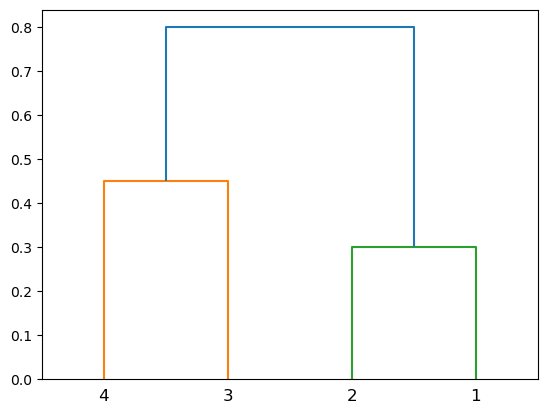

In [5]:
dendrogram(linkage([0.3,0.4,0.7,0.5,0.8,0.45],method='complete'),labels=[1,2,3,4],show_leaf_counts=True,count_sort='descending')
plt.show()

## Q3.
```{admonition}
:class: note
In this problem, you will perform K-means clustering manually, with $K = 2$, on a small example with $n = 6$ observations and $p = 2$ features. The observations are as follows.
    
|Obs.|$X_1$|$X_2$|
|----|--|--|
| 1  | 1| 4|
| 2  | 1| 3|
| 3  | 0| 4|
| 4  | 5| 1|
| 5  | 6| 2|
| 6  | 4| 0|

```{admonition}
:class: note
(a) Plot the observations.

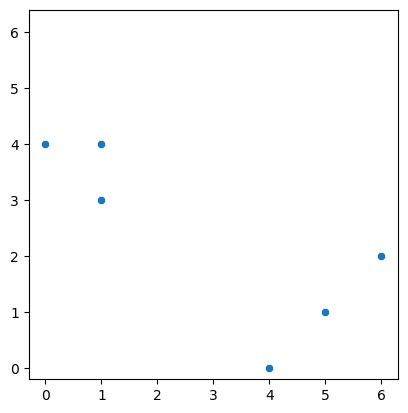

In [6]:
obs = np.array([[1,1,0,5,6,4],[4,3,4,1,2,0]]).T
sns.scatterplot(x=obs[:,0],y=obs[:,1])
plt.xticks(np.arange(0,7))
plt.yticks(np.arange(0,7))
plt.axis('square')
plt.show()

```{admonition}
:class: note
(b) Randomly assign a cluster label to each observation. Report the cluster labels for each observation.

In [7]:
rng = np.random.default_rng(1728)
cluster_label = rng.integers(0,2,size=6)
for i, lab in enumerate(cluster_label):
    print(f'Obs. {i+1} label: {lab}')
c0 = obs[cluster_label==0,:]
c1 = obs[cluster_label==1,:]

Obs. 1 label: 0
Obs. 2 label: 1
Obs. 3 label: 0
Obs. 4 label: 1
Obs. 5 label: 1
Obs. 6 label: 1


```{admonition}
:class: note
(c) Compute the centroid for each cluster.

In [8]:
centroids = np.array([np.mean(c0,axis=0),np.mean(c1,axis=0)])

```{admonition}
:class: note
(d) Assign each observation to the centroid to which it is closest, in terms of Euclidean distance. Report the cluster labels for each observation.

In [9]:
cluster_label_new = np.argmin(np.linalg.norm(obs[None,:,:]-centroids[:,None,:],axis=2),axis=0)
for i, lab in enumerate(cluster_label_new):
    print(f'Obs. {i+1} label: {lab}')
c0 = obs[cluster_label==0,:]
c1 = obs[cluster_label==1,:]

Obs. 1 label: 0
Obs. 2 label: 0
Obs. 3 label: 0
Obs. 4 label: 1
Obs. 5 label: 1
Obs. 6 label: 1


```{admonition}
:class: note
(e) Repeat (c) and (d) until the answers obtained stop changing.

In [10]:
cluster_label_old = None
while (cluster_label_old != cluster_label_new).any():
    cluster_label_old = cluster_label_new.copy()
    centroids = np.array([np.mean(c0,axis=0),np.mean(c1,axis=0)])
    cluster_label_new = np.argmin(np.linalg.norm(obs[None,:,:]-centroids[:,None,:],axis=2),axis=0)
    c0 = obs[cluster_label==0,:]
    c1 = obs[cluster_label==1,:]
print('Cluster labels stopped changing')

Cluster labels stopped changing


```{admonition}
:class: note
(f) In your plot from (a), color the observations according to the cluster labels obtained.

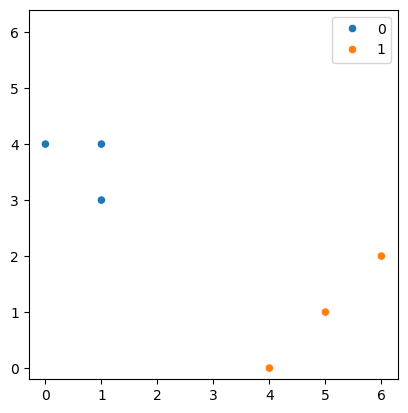

In [11]:
sns.scatterplot(x=obs[:,0],y=obs[:,1],hue=cluster_label_new)
plt.xticks(np.arange(0,7))
plt.yticks(np.arange(0,7))
plt.axis('square')
plt.show()

## Q4.
```{admonition}
:class: note
Suppose that for a particular data set, we perform hierarchical clustering using single linkage and using complete linkage. We obtain two dendrograms.

```{admonition}
:class: note
(a) At a certain point on the single linkage dendrogram, the clusters $\{1, 2, 3\}$ and $\{4, 5\}$ fuse. On the complete linkage dendrogram, the clusters $\{1, 2, 3\}$ and $\{4, 5\}$ also fuse at a certain point. Which fusion will occur higher on the tree, or will they fuse at the same height, or is there not enough information to tell?

There is not enough information. Complete linkage compares the largest inter-cluster distance, so it would typically fuse above single linkage which comparest the smallest instead; however, if the distances are all the same, then they would fuse at the same height.

```{admonition}
:class: note
(b) At a certain point on the single linkage dendrogram, the clusters $\{5\}$ and $\{6\}$ fuse. On the complete linkage dendrogram, the clusters $\{5\}$ and $\{6\}$ also fuse at a certain point. Which fusion will occur higher on the tree, or will they fuse at the same height, or is there not enough information to tell?

Same height. Since the clusters are only a single point, there is no difference in distance calculation between the choices.

## Q5.
```{admonition}
:class: note
In words, describe the results that you would expect if you performed $K$-means clustering of the eight shoppers below, on the basis of their sock and computer purchases, with $K = 2$. Give three answers, one for each of the variable scalings displayed.

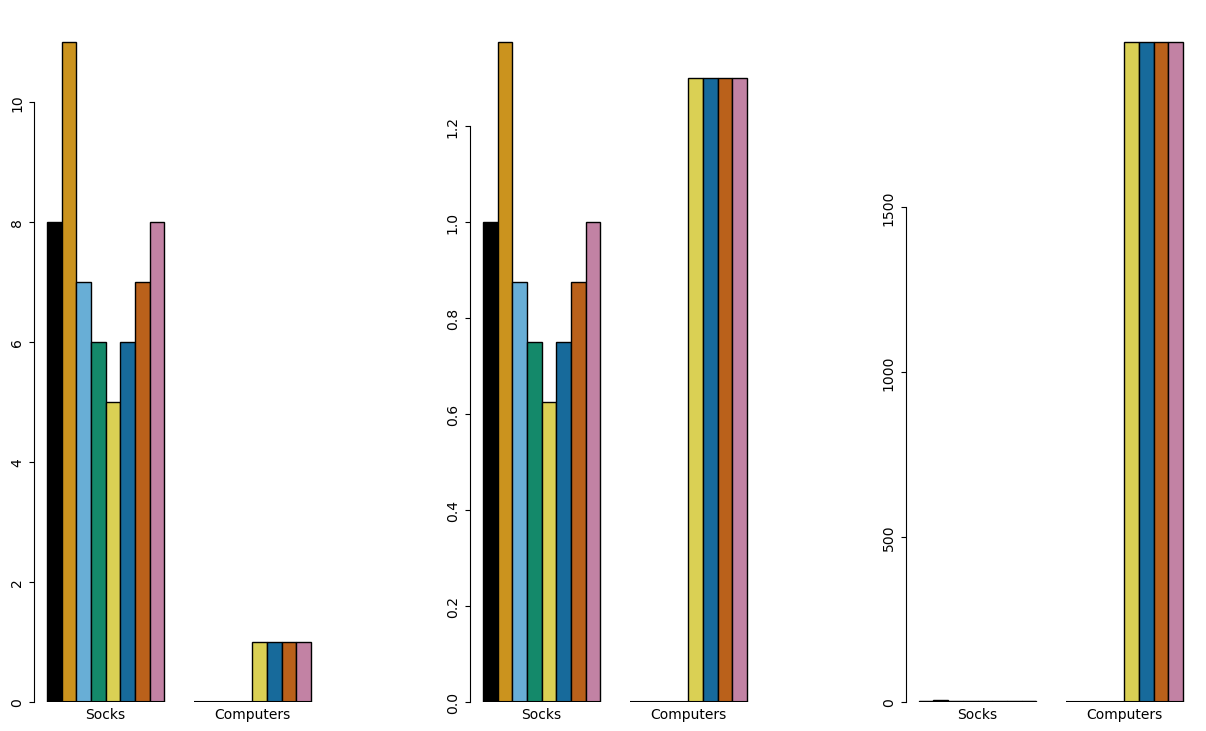

In [12]:
df = pd.DataFrame({
    'Cat': ['Socks']*8+['Computers']*8,
    'Person': [i for i in range(8)]*2,
    'Quant': [8,11,7,6,5,6,7,8]+[0]*4+[1]*4,
    'Cost': [2]+[5]+[2]*6+[0]*4+[2000]*4
})
df[['Quant','Cost']] = df[['Quant','Cost']].astype(float)
df_scale = df.copy()
df_scale.iloc[:8,2] = df_scale.iloc[:8,2]/8
df_scale.iloc[8:,2] = df_scale.iloc[8:,2]*1.3

colors = ["#000000","#e89d01",'#55b3e9','#009d73','#f0e33e','#0170b1','#d55e00','#cd77a5']

fig, ax = plt.subplots(1,3,figsize=(15,9))
ax = ax.flatten()

sns.barplot(data=df,x='Cat',y='Quant',hue='Person',palette=colors,edgecolor='black',legend=False,ax=ax[0])
ax[0].set_yticks(np.arange(0,11,2))

sns.barplot(data=df_scale,x='Cat',y='Quant',hue='Person',palette=colors,edgecolor='black',legend=False,ax=ax[1])
ax[1].set_yticks(np.arange(0,1.3,.2))

sns.barplot(data=df,x='Cat',y='Cost',hue='Person',palette=colors,edgecolor='black',legend=False,ax=ax[2])
ax[2].set_yticks(np.arange(0,1600,500))

for axis in ax:
    sns.despine(ax=axis,top=True,right=True,bottom=True)
    axis.set_xlabel('')
    axis.set_ylabel('')
    axis.tick_params(axis='x',length=0)
    axis.tick_params(axis='y',rotation=90)
    for label in axis.get_yticklabels():
        label.set_verticalalignment('center')
    axis.spines['left'].set_bounds(*axis.get_yticks()[[0,-1]])
    axis.hlines(0,-0.4,0.4,color='k')
    axis.hlines(0,0.6,1.4,color='k')
    

fig.subplots_adjust(wspace=0.5)
plt.show()

For the first, the two clusters should primarily depend on the quantity of socks purchased, since a computer purchase adds only a minor distance increase.

For the second, the features are closer in magnitude so a computer purchase now adds a moderate separating distance between points. We may expect clusters to form based on distinct items purchase, which in this case would be clusters around whether the person purchased a computer.

For the third, the computer price feature dominates. In this case, we would expect clusters similar to the second formed based on purchasing a computer.

## Q6.
```{admonition}
:class: note
We saw that the principal component loading and score vectors provide an approximation to a matrix. Specifically, the principal component score and loading vectors
solve the optimization problem given by
$$
\operatorname*{minimize}_{\mathbf{A}\in\mathbb{R}^{n\times M},\mathbf{B}\in\mathbb{R}^{p\times M}} \left\{\sum_{j=1}^{p}\sum_{i=1}^{n}\left(x_{ij}-\sum_{m=1}^{M} a_{im}b_{jm}\right)^{2}\right\}.
$$

Now, suppose that the $M$ principal component score vectors $z_{im}$ with $m = 1, \dots , M$ are known. Using the above, explain that each of the first $M$ principal component loading vectors $\varphi_{jm}$ can be obtained by performing $p$ separate least squares linear regressions. In each regression, the principal component score vectors are the predictors, and one of the features of the data matrix is the response.

Assuming we know the $z_{im}$, we are seeking to find $b_{jm}$ that minimize
$$
\sum_{j=1}^{p}\sum_{i=1}^{n}\left(x_{ij}-\sum_{m=1}^{M} z_{im}b_{jm}\right)^{2}.
$$
We may minimize this sum by minimizing each term of the outer sum as there is no interaction between terms. That is, for each $j$ we are seeking to find $b_{jm}$ minimize
$$
\sum_{i=1}^{n}\left(x_{ij}-\sum_{m=1}^{M} z_{im}b_{jm}\right)^{2}.
$$
But this is exactly least squares regression of $X_{j}$ onto $z_{im}$. The solution to these least squares combine to minimize the objective above, and we know that $\varphi_{jm}$ are the coefficients that, when combined with $z_{im}$, give a solution. Therefore $b_{jm} = \varphi_{jm}$.